# Task 3: Perceptron Algorithm for 3 vs 5 Classification

## 1. Objective
In this task, we extend our Perceptron implementation to classify digits 3 and 5 from the MNIST dataset. Unlike 0 and 1, digits 3 and 5 are more structurally similar, making them a more challenging test for a linear classifier.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df_3_5 = pd.read_csv("mnist_3_and_5.csv")

# Extract features and labels
X = df_3_5.drop(columns=["label"]).values
y = df_3_5["label"].values

# Note: The dataset uses 3 and 5 as labels. 
# For a binary perceptron (0/1 output), we map these to 0 and 1.
y_mapped = np.where(y == 3, 0, 1)

print("Feature matrix shape:", X.shape)
print("Unique labels in original data:", np.unique(y))
print("Unique labels after mapping:", np.unique(y_mapped))

Feature matrix shape: (2741, 784)
Unique labels in original data: [3 5]
Unique labels after mapping: [0 1]


### Visualize 3s and 5s

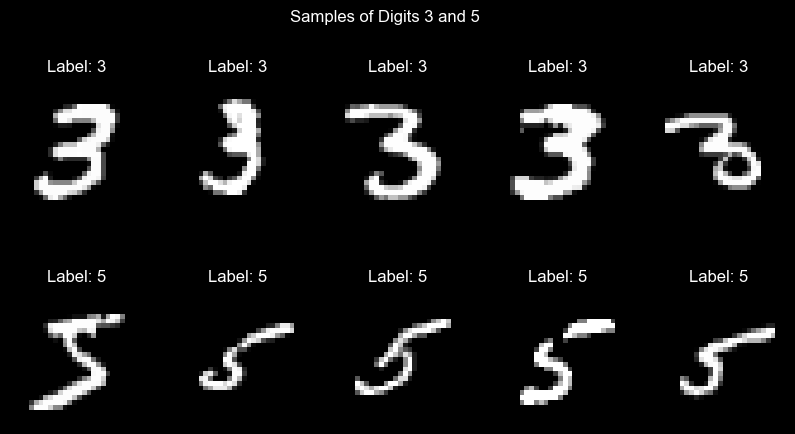

In [2]:
images_3 = X[y == 3]
images_5 = X[y == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(min(len(images_3), 5)):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")
for i in range(min(len(images_5), 5)):
    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")

plt.suptitle("Samples of Digits 3 and 5")
plt.show()

## 2. Implementation
We use the same Perceptron logic as Task 2.

In [3]:
def train_perceptron(X, y, learning_rate=0.1, epochs=20):
    weights = np.zeros(X.shape[1])
    bias = 0
    n_samples = X.shape[0]
    
    history = []
    
    for epoch in range(epochs):
        errors = 0
        for i in range(n_samples):
            z = np.dot(X[i], weights) + bias
            y_hat = 1 if z >= 0 else 0
            
            if y_hat != y[i]:
                update = learning_rate * (y[i] - y_hat)
                weights += update * X[i]
                bias += update
                errors += 1
        
        accuracy = 1 - (errors / n_samples)
        history.append(accuracy)
        
        if (epoch + 1) % 1 == 0:
            print(f"Epoch {epoch+1}/{epochs}: Accuracy = {accuracy:.4f}")
            
        if errors == 0:
            print(f"Converged at epoch {epoch+1}")
            break
            
    return weights, bias, history

# Train on 3 vs 5
weights, bias, history = train_perceptron(X, y_mapped, epochs=20)

Epoch 1/20: Accuracy = 0.9157
Epoch 2/20: Accuracy = 0.9372
Epoch 3/20: Accuracy = 0.9416
Epoch 4/20: Accuracy = 0.9475
Epoch 5/20: Accuracy = 0.9489
Epoch 6/20: Accuracy = 0.9504
Epoch 7/20: Accuracy = 0.9599
Epoch 8/20: Accuracy = 0.9559
Epoch 9/20: Accuracy = 0.9540
Epoch 10/20: Accuracy = 0.9566
Epoch 11/20: Accuracy = 0.9599
Epoch 12/20: Accuracy = 0.9580
Epoch 13/20: Accuracy = 0.9657
Epoch 14/20: Accuracy = 0.9602
Epoch 15/20: Accuracy = 0.9635
Epoch 16/20: Accuracy = 0.9657
Epoch 17/20: Accuracy = 0.9606
Epoch 18/20: Accuracy = 0.9624
Epoch 19/20: Accuracy = 0.9610
Epoch 20/20: Accuracy = 0.9661


## 3. Visualize Misclassified Images and Conclusion

Total Misclassified: 126 out of 2741
Final Accuracy: 0.9540


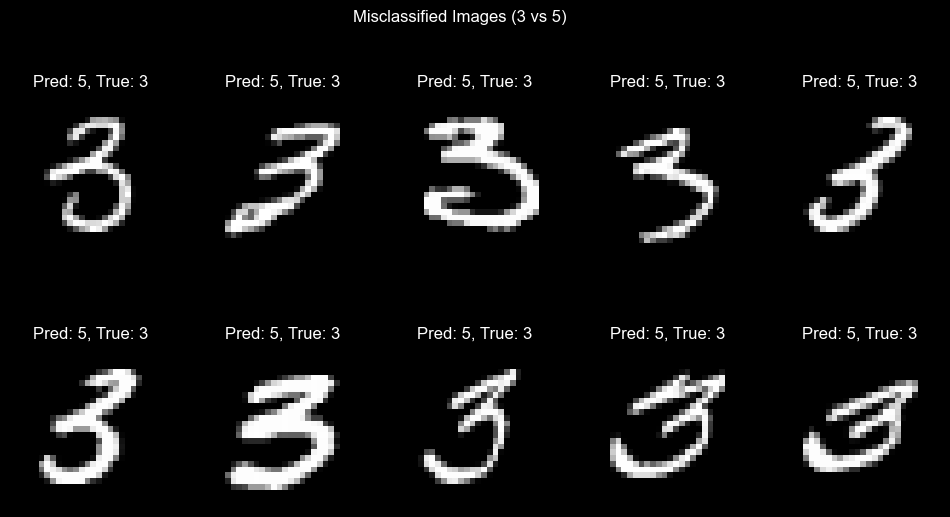

In [4]:
z_final = np.dot(X, weights) + bias
y_pred = np.where(z_final >= 0, 1, 0)
misclassified_idx = np.where(y_pred != y_mapped)[0]

print(f"Total Misclassified: {len(misclassified_idx)} out of {len(y_mapped)}")
print(f"Final Accuracy: {1 - len(misclassified_idx)/len(y_mapped):.4f}")

if len(misclassified_idx) > 0:
    n_to_show = min(len(misclassified_idx), 10)
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    for ax, idx in zip(axes.flat, misclassified_idx[:n_to_show]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        pred_val = 5 if y_pred[idx] == 1 else 3
        true_val = 5 if y_mapped[idx] == 1 else 3
        ax.set_title(f"Pred: {pred_val}, True: {true_val}")
        ax.axis("off")
    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.show()
else:
    print("All images were correctly classified!")

### Conclusion

Based on the results, we can observe that:
1. **Difficulty:** The Perceptron achieved lower accuracy (or took longer to converge) compared to the 0 vs 1 task. This is because 3 and 5 share many overlapping pixels, making them less "linearly separable."
2. **Misclassifications:** The images our model missed are often poorly written or ambiguous even to the human eye (e.g., a 5 that looks like a 3 because the top bar is curved).
3. **Model Limitation:** As a linear classifier, the Perceptron is limited to finding a straight line (hyperplane) in the 784-dimensional space. To improve results, we would likely need a non-linear model like a Multi-Layer Perceptron (Neural Network) or a Convolutional Neural Network (CNN).